**1: Project Introduction Fake News Detection using BERT**

## Problem Statement

Fake news spreads quickly on social media and news platforms. Traditional machine learning models rely heavily on manual feature engineering and often fail to understand the semantic meaning of text.

In this project, we use BERT (Bidirectional Encoder Representations from Transformers), a transformer-based deep learning model, to classify news articles as Real or Fake.

## Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Transformers (Hugging Face)
- PyTorch
- Scikit-learn
- Matplotlib
- Seaborn

## Deep Learning Model

- bert-base-uncased

## **2: Install Libraries**


In [25]:
!pip install transformers datasets accelerate -q
# #We need:

# transformers → Loads pretrained BERT models.
# datasets → Optional utility for datasets.
# accelerate → Speeds up model training.

# **3: Import Libraries**

In [26]:
import pandas as pd
import numpy as np

import torch

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

from transformers import BertTokenizer

# Explain each import:

# pandas → Reads CSV.
# numpy → Numerical operations.
# torch → Deep Learning framework.
# transformers → Loads BERT.
# train_test_split → Splits the dataset.

# **4: Load Dataset**

In [27]:
import pandas as pd

fake = pd.read_csv("Fake.csv", nrows=5)
print(fake)

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


In [28]:
import os

print(os.path.getsize("Fake.csv"))
print(os.path.getsize("True.csv"))

62789876
53582940


In [29]:
fake = pd.read_csv(
    "Fake.csv",
    engine="python"
)

In [30]:
true = pd.read_csv(
    "True.csv",
    engine="python"
)

In [31]:
fake = pd.read_csv("Fake.csv")

true = pd.read_csv("True.csv")

In [32]:
print(fake.shape)
print(true.shape)

(23481, 4)
(21417, 4)


In [33]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [34]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


# **5: Add Labels**

In [35]:
fake["label"] = 0

In [36]:
true["label"] = 1

In [37]:
df = pd.concat([fake, true], axis=0)

In [38]:
df = df.sample(frac=1).reset_index(drop=True)

6: Explore Dataset

In [39]:
df.head()

,title,text,subject,date,label
0,SUB-HUMANS: Surveillance VIDEO Captures 4 Blac...,A group of people beat a man in a Brooklyn res...,left-news,"Mar 15, 2017",0
1,"Trump Crosses The Line, Attacks Civil Rights ...",Georgia Congressman John Lewis is one of Ameri...,News,"January 14, 2017",0
2,Trump backs off ISIS comments; party head appe...,"ALTOONA, Pa. (Reuters) - Republican Donald Tru...",politicsNews,"August 12, 2016",1
3,Russia takes Tokyo to task over defense allian...,MOSCOW (Reuters) - Russia is concerned that Ja...,worldnews,"November 24, 2017",1
4,UK's May to visit China around Jan. 31: Sky News,(Reuters) - British Prime Minister Theresa May...,worldnews,"December 20, 2017",1


In [40]:
df.shape

(44898, 5)

In [41]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [42]:
df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [43]:
df["label"].value_counts()

,count
label,
0,23481
1,21417


7: Data Cleaning

In [44]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [45]:
df["text"] = df["text"].apply(clean_text)

8: Train Test Split

In [46]:
X = df["text"]

In [47]:
y = df["label"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

9: Introduction to BERT
10: BERT Tokenizer

In [49]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [50]:
sample = X_train.iloc[0]

encoding = tokenizer(

    sample,

    padding="max_length",

    truncation=True,

    max_length=128,

    return_tensors="pt"

)

11: Inspect Tokenization

In [51]:
encoding.keys()

KeysView({'input_ids': tensor([[  101,  1996,  2343,  1055,  3942, 14082,  2013,  5958,  5027,  2000,
          6928,  2851,  2043,  2002,  2097,  3604,  2000,  6097,  4305,  3363,
          2250,  2486,  2918,  1999,  9925,  2002,  1055,  2059,  3517,  2000,
          2132,  2067,  2000,  2899,  5887,  5886,  2063,  2024,  2274,  3145,
          2477,  2000,  2113,  2096,  8398,  2003,  1999,  2237,  2023,  2003,
          8398,  1055,  2034,  3942,  2000,  5340,  3509,  2144,  2010,  5553,
         17331,  4783, 29278,  2063,  2023,  4440,  8398,  1055,  2197,  3942,
          2000,  2010,  5340,  3509,  2188,  2001,  2058,  1996,  4234,  1998,
          2047,  2095,  1055, 11938,  2043,  2002,  2001,  2145,  2343, 12260,
          6593, 19927,  1999,  2237,  2002,  2209,  5439,  3807,  2320,  2007,
          6816,  5249,  2012,  8398,  1055,  2225,  5340,  3509,  5439,  2607,
          1998,  1037,  2117,  2051,  2006,  2047,  2095,  1055,  6574,  2012,
          1996,  8398,  2120,

In [52]:
encoding["input_ids"]  #View IDs

tensor([[  101,  1996,  2343,  1055,  3942, 14082,  2013,  5958,  5027,  2000,
          6928,  2851,  2043,  2002,  2097,  3604,  2000,  6097,  4305,  3363,
          2250,  2486,  2918,  1999,  9925,  2002,  1055,  2059,  3517,  2000,
          2132,  2067,  2000,  2899,  5887,  5886,  2063,  2024,  2274,  3145,
          2477,  2000,  2113,  2096,  8398,  2003,  1999,  2237,  2023,  2003,
          8398,  1055,  2034,  3942,  2000,  5340,  3509,  2144,  2010,  5553,
         17331,  4783, 29278,  2063,  2023,  4440,  8398,  1055,  2197,  3942,
          2000,  2010,  5340,  3509,  2188,  2001,  2058,  1996,  4234,  1998,
          2047,  2095,  1055, 11938,  2043,  2002,  2001,  2145,  2343, 12260,
          6593, 19927,  1999,  2237,  2002,  2209,  5439,  3807,  2320,  2007,
          6816,  5249,  2012,  8398,  1055,  2225,  5340,  3509,  5439,  2607,
          1998,  1037,  2117,  2051,  2006,  2047,  2095,  1055,  6574,  2012,
          1996,  8398,  2120,  5439,  2252,  1999, 1

In [53]:
encoding["attention_mask"]  #View Attention Mask

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]])

In [54]:
tokenizer.convert_ids_to_tokens(

encoding["input_ids"][0]

)    #Convert IDs back to tokens

['[CLS]',
 'the',
 'president',
 's',
 'visit',
 'stretches',
 'from',
 'friday',
 'afternoon',
 'to',
 'monday',
 'morning',
 'when',
 'he',
 'will',
 'travel',
 'to',
 'mac',
 '##di',
 '##ll',
 'air',
 'force',
 'base',
 'in',
 'tampa',
 'he',
 's',
 'then',
 'expected',
 'to',
 'head',
 'back',
 'to',
 'washington',
 'dc',
 '##her',
 '##e',
 'are',
 'five',
 'key',
 'things',
 'to',
 'know',
 'while',
 'trump',
 'is',
 'in',
 'town',
 'this',
 'is',
 'trump',
 's',
 'first',
 'visit',
 'to',
 'palm',
 'beach',
 'since',
 'his',
 'jan',
 'inauguration',
 '##be',
 '##for',
 '##e',
 'this',
 'trip',
 'trump',
 's',
 'last',
 'visit',
 'to',
 'his',
 'palm',
 'beach',
 'home',
 'was',
 'over',
 'the',
 'christmas',
 'and',
 'new',
 'year',
 's',
 'holidays',
 'when',
 'he',
 'was',
 'still',
 'president',
 '##ele',
 '##ct',
 '##while',
 'in',
 'town',
 'he',
 'played',
 'golf',
 'twice',
 'once',
 'with',
 'tiger',
 'woods',
 'at',
 'trump',
 's',
 'west',
 'palm',
 'beach',
 'golf',
 '

12: Create Inputs for All Data

In [55]:
def tokenize_data(texts):

    return tokenizer(

        list(texts),

        padding=True,

        truncation=True,

        max_length=128,

        return_tensors="pt"

    )

In [56]:
train_encodings = tokenize_data(X_train)

test_encodings = tokenize_data(X_test)

In [57]:
train_encodings["input_ids"].shape

torch.Size([35918, 128])

13: Create PyTorch Dataset

In [58]:
from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [59]:
train_dataset = FakeNewsDataset(train_encodings, y_train)

test_dataset = FakeNewsDataset(test_encodings, y_test)

14: DataLoader

In [60]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16
)

15: Load BERT Model

In [61]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


16:gpu

In [62]:
# check gpu
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [63]:
#move model
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [64]:
print(device)

cuda


In [65]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [67]:
model = model.to(device)
print(next(model.parameters()).device)

cuda:0


17:Optimizer

In [68]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

18:Training Loop

In [69]:
from tqdm import tqdm

model.train()

epochs = 2

for epoch in range(epochs):

    total_loss = 0

    for batch in tqdm(train_loader):

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(
            input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}")

    print(f"Loss = {total_loss}")

100%|██████████| 2245/2245 [15:46<00:00,  2.37it/s]


Epoch 1
Loss = 30.96353507736785


100%|██████████| 2245/2245 [15:54<00:00,  2.35it/s]

Epoch 2
Loss = 8.245926394389244


19:Evaluation

In [70]:
model.eval()

predictions = []

true_labels = []

In [71]:
with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(
            input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())

        true_labels.extend(labels.cpu().numpy())

20:Metrics

In [72]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    true_labels,
    predictions
)

print(accuracy)

0.9991091314031181


In [73]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4740
           1       1.00      1.00      1.00      4240

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



21:Confusion Matrix

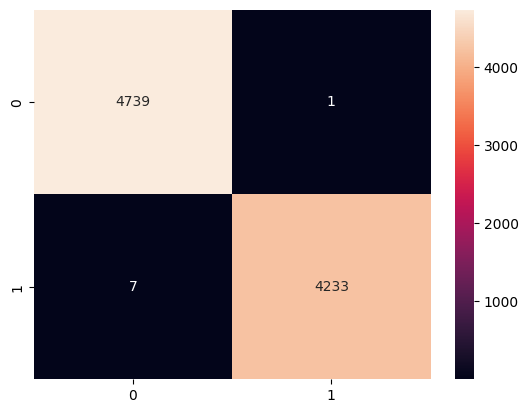

In [74]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    predictions
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.show()

22:Predict new news

In [75]:
def predict_news(news):

    encoding = tokenizer(
        news,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    input_ids = encoding["input_ids"].to(device)

    attention_mask = encoding["attention_mask"].to(device)

    model.eval()

    with torch.no_grad():

        output = model(
            input_ids,
            attention_mask=attention_mask
        )

        prediction = torch.argmax(
            output.logits,
            dim=1
        )

    return "Real" if prediction.item()==1 else "Fake"

In [76]:
news = """
NASA successfully launches new satellite into space.
"""

print(
    predict_news(news)
)

Fake


23:Save model

In [77]:
model.save_pretrained("fake_news_model")

tokenizer.save_pretrained("fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_model/tokenizer_config.json', 'fake_news_model/tokenizer.json')

24:load model

In [78]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "fake_news_model"
)

tokenizer = BertTokenizer.from_pretrained(
    "fake_news_model"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [79]:
import torch

In [80]:
def predict_news(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()

    if prediction == 1:
        print("🟢 Prediction: Real News")
    else:
        print("🔴 Prediction: Fake News")

In [81]:
predict_news("The Indian government announced a new education policy.")

🔴 Prediction: Fake News


In [82]:
predict_news("NASA launches a new satellite.")

🔴 Prediction: Fake News


In [83]:
df.sample(5)

,title,text,subject,date,label
11751,BREAKING DALLAS: DPD Chief Confirms 10 Officer...,update suspect in custody suspect pinned downd...,left-news,"Jul 7, 2016",0
177,Trump spokesman says of possibility of U.S. Em...,washington reuters presidentelect donald trump...,politicsNews,"January 19, 2017",1
28334,MILITARY LEADERS SPEAK UP: IRAN DEAL MAKES WAR...,john kerry insinuated that war would be more l...,Government News,"Sep 3, 2015",0
39168,Seven-Year-Old Boy Accidentally Kills Father ...,a sevenyearold alma michigan boy accidentally ...,News,"July 8, 2016",0
23188,Exclusive: Special counsel Mueller to probe ex...,washington reuters robert mueller the special ...,politicsNews,"June 2, 2017",1


In [84]:
predict_news(df.iloc[100]["text"])

🟢 Prediction: Real News


In [85]:
df.iloc[107]["text"]

'beirut reuters the usled coalition told reuters on friday that it does not have any releasable information concerning the whereabouts of islamic state leader abu bakr albaghdadi a military media unit run by the iranbacked hezbollah said on friday that baghdadi was reported present in the syrian town of albu kamal during the syrian army and its allies operation to clear it the report did not say if baghdadi was captured '

In [86]:
predict_news(df.iloc[1]["text"])

🔴 Prediction: Fake News


In [87]:
predict_news(df.iloc[18]["text"])

🟢 Prediction: Real News


In [88]:
predict_news(df.iloc[1089]["text"])

🔴 Prediction: Fake News


In [89]:
predict_news(df.iloc[1730]["text"])

🔴 Prediction: Fake News


# Conclusion

In this project, I developed a Fake News Detection system using Google's BERT Transformer model.

The project demonstrates the complete Natural Language Processing (NLP) pipeline:

- Data preprocessing and cleaning
- BERT tokenization
- Fine-tuning a pretrained BERT model
- Model evaluation using accuracy, precision, recall, and F1-score
- Predicting whether custom news articles are Real or Fake

This project strengthened my understanding of Deep Learning, Transformer models, transfer learning, and text classification using PyTorch and Hugging Face Transformers.

### Future Improvements

- Deploy the model using Streamlit or Flask
- Extend support for multilingual fake news detection
- Improve model explainability using SHAP or LIME
- Evaluate the model on larger and more diverse datasets